## Data preparationnn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv").set_index("Id")

print(df.isna().sum())

df

suhu_operasi                   0
tekanan_hidrolik               0
getaran_motor                  0
arus_listrik                   0
kelembapan_ruang               0
laju_produksi                  0
usia_mesin_hari                0
deviasi_kalibrasi              0
tegangan_panel                 0
kecepatan_kipas_pendingin      0
kadar_debu_partikel            0
jam_shift                      0
suhu_lingkungan_luar           0
stabilitas_jaringan_listrik    0
intensitas_pencahayaan         0
waktu_idle_mesin_menit         0
Tindakan                       0
dtype: int64


,suhu_operasi,tekanan_hidrolik,getaran_motor,arus_listrik,kelembapan_ruang,laju_produksi,usia_mesin_hari,deviasi_kalibrasi,tegangan_panel,kecepatan_kipas_pendingin,kadar_debu_partikel,jam_shift,suhu_lingkungan_luar,stabilitas_jaringan_listrik,intensitas_pencahayaan,waktu_idle_mesin_menit,Tindakan
Id,,,,,,,,,,,,,,,,,
1,70.285378,97.420479,0.911697,12.871336,47.417994,297.724077,2573,-0.100432,-0.322599,-0.563671,2.122922,-0.306064,-0.214880,0.723267,-1.991227,-0.119264,2
3,73.628384,93.033401,0.334705,12.549843,63.419680,295.249384,2946,0.146816,-0.626401,-1.000615,-1.224947,1.469401,0.669142,-1.753121,0.395518,0.059857,1
4,75.054235,104.284829,0.750146,11.992199,58.000909,286.563884,2060,-0.081530,0.559280,-1.647869,1.638428,0.798942,-0.319706,-0.523548,0.917377,-1.890144,0
6,58.233654,84.093503,0.872960,11.699609,74.367708,293.435937,1534,-0.107728,1.087835,0.119715,-0.150623,-0.961511,-0.339706,0.558171,0.687283,-1.870696,0
7,68.958803,83.484740,1.363567,11.933675,71.312405,246.603789,2159,0.762197,-0.734981,-1.793328,0.675739,-1.375680,0.287863,0.318171,0.798231,-0.073837,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,71.215608,93.729041,0.653193,9.463369,61.896317,268.897738,1878,0.457260,0.404844,-1.863253,0.979102,-1.843792,-0.019061,-0.135386,-0.896376,0.626842,1
4997,65.425582,99.368202,0.847833,9.738186,59.753916,301.658620,2751,-0.014276,0.302796,-0.450749,-0.182647,0.274548,-0.390887,1.935914,1.585842,0.749449,0
4998,73.855108,100.852488,0.424096,12.354362,64.214301,360.383098,1580,-0.219967,0.059637,0.208083,0.739698,1.322904,-0.781929,1.496474,-0.832191,0.150584,0


In [92]:
from sklearn.model_selection import train_test_split

xall, yall = df.iloc[:, :-1].to_numpy(), df.iloc[:, -1].to_numpy()

x, xt, y, yt = train_test_split(xall, yall, test_size=0.15, random_state=67)

<Axes: >

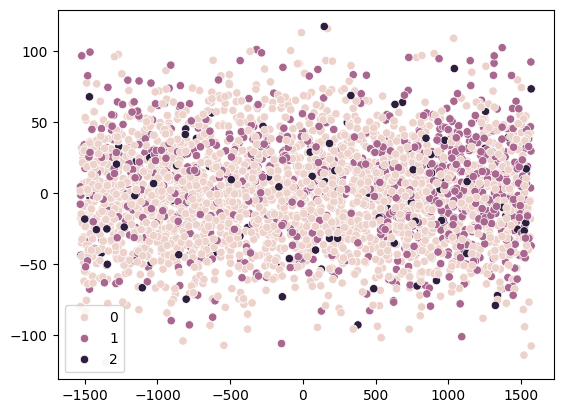

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
xpca = pca.fit_transform(x)

sns.scatterplot(x=xpca[:, 0],y=xpca[:, 1], hue=y)

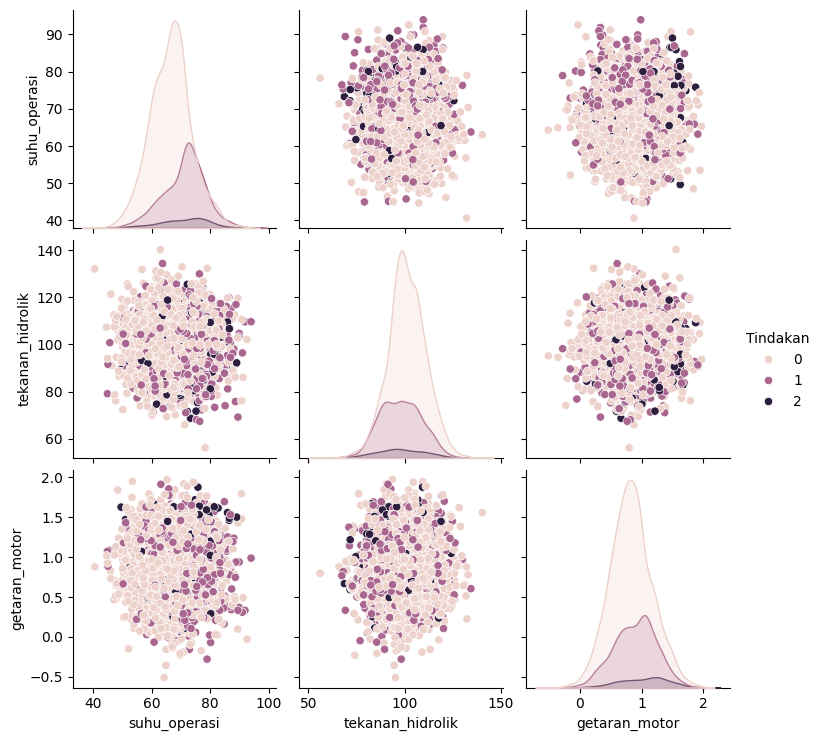

In [5]:
sns.pairplot(data=df, x_vars=df.columns[:3], y_vars=df.columns[:3], hue=df.columns[-1])

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=67)

def custom_score(fitted_estimator, xt, yt):
    pred = fitted_estimator.predict(xt)

    score = f1_score(yt, pred, average="macro")
    final = score - 0.02 * fitted_estimator.get_depth() - 0.002 * fitted_estimator.tree_.node_count
    return final

def plot_params(valrange, paramsname):
    gscv = GridSearchCV(
        estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=81),
        param_grid={
            paramsname: valrange
        },
        cv=skf,
        scoring=custom_score
    )
    gscv.fit(x, y)

    dfgs = pd.DataFrame(gscv.cv_results_)

    scores = np.c_[valrange, dfgs["mean_test_score"]]
    sns.lineplot(x=scores[:, 0], y=scores[:, 1], drawstyle="steps-post")

    testscores = []
    for ps in dfgs["params"]:
        curmodel = DecisionTreeClassifier(**ps)
        curmodel.fit(x, y)

        curscore = custom_score(curmodel, xt, yt)
        testscores.append(curscore)

    sns.lineplot(x=scores[:, 0], y=testscores[:], drawstyle="steps-post")
    plt.title(paramsname)
    return gscv.best_params_

In [40]:
print(len(DecisionTreeClassifier().get_params()))

13


{'max_depth': np.int64(3)}

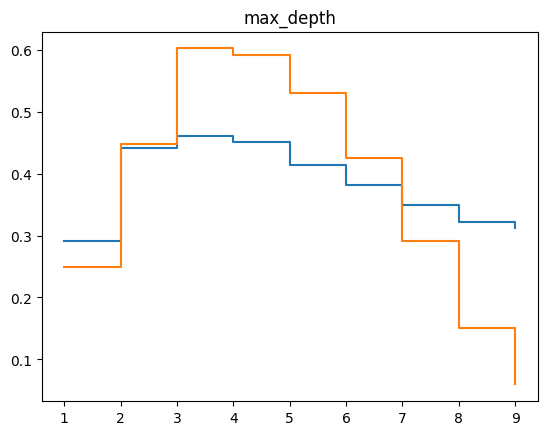

In [8]:
plot_params(np.arange(1, 10, 1), "max_depth")

{'min_samples_leaf': np.int64(75)}

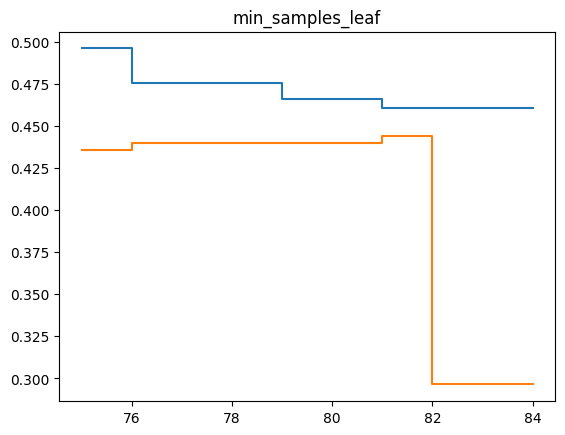

In [9]:
plot_params(np.arange(75, 85, 1), "min_samples_leaf")

{'min_samples_split': np.int64(425)}

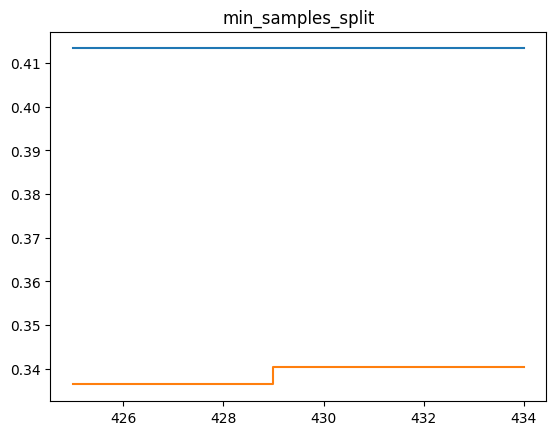

In [10]:
plot_params(np.arange(425, 435, 1), "min_samples_split")

In [93]:
bestmodel = DecisionTreeClassifier(max_depth=3, min_samples_leaf=1, min_samples_split=2, max_features=13, random_state=67)
bestmodel.fit(x, y)

print(bestmodel.get_depth())
print(bestmodel.tree_.node_count)

print(custom_score(bestmodel, xt, yt )) # hmm testing on itself awokawokaok

3
15
0.608221638505088


In [94]:
import joblib
joblib.dump(bestmodel, "model-loselen.joblib")

['model-loselen.joblib']